# Quality of Life and Happiness Analysis

### Abstract

This project investigates how external socioeconomic factors influence Quality of Life and Happiness Score across different countries over the period from 2015 to 2022. Two datasets were merged — the World Happiness Report and the Quality of Life Index by Country — to enable a comprehensive cross-analysis of indicators such as Social Support, Freedom, Generosity, Trust in Government, Purchasing Power, Safety, and Pollution. The analysis includes descriptive statistics, trend visualization, correlation analysis, and hypothesis testing aimed at identifying which factors most strongly drive well-being at a national level.

The project was completed by a team of two. Data loading, merging, cleanup, and hypothesis formulation were shared equally between both team members. Visualizations and descriptive analysis of the World Happiness dataset were handled primarily by Sofia, while analysis of the Quality of Life dataset was handled primarily by Anastasia.

# World Happiness Dataset

### Dataset Description


Dataset source:

https://www.kaggle.com/datasets/hari31416/world-happiness-report/data
The datasets belong to the field of social and economic statistics.

They contain annual data for multiple countries from 2015 to 2022 and include indicators such as economic conditions (GDP per capita), social support (Family), healthy life expectancy (Health), freedom to make life choices (Freedom), generosity, trust in institutions, and overall happiness scores.

For further analysis, the datasets will be merged into a single table using the additional **Year** column, which allows matching records from different years and enables time-series analysis.

In [110]:
import pandas as pd

In [111]:
tables = []
years = range(2015, 2023)

for year in years:
    table = pd.read_csv(f"../data_sets/{year}.csv")
    table["Year"] = year
    tables.append(table)


Before merging the datasets, it is needed to examine their structure and verify whether the columns are consistent across all years.

In [112]:
reference_year = tables[0]


for i in range(len(tables)):
    if tables[i].columns.equals(reference_year.columns):
        print(f"{years[i]}: equal")
    else:
        print(f"{years[i]}: {set(tables[i].columns)^set(reference_year.columns)}")

2015: equal
2016: equal
2017: equal
2018: {'Dystopia'}
2019: {'Dystopia'}
2020: equal
2021: equal
2022: equal


The comparison of column names showed that the datasets do not have completely identical structures: the datasets for 2018 and 2019 do not contain the Dystopia column, while all other years include it.

Since the purpose of this project is to analyze variables that are available for every year, the datasets will be combined using only the columns that are present in all tables.

In [113]:
all_data = pd.concat(tables, axis = 0, join = 'inner', ignore_index = True)

In [114]:
all_data.head()

,Country,Region,Happiness Rank,Happiness Score,Economy,Family,Health,Freedom,Generosity,Trust,Year
0,Switzerland,Western Europe,1,7.587,1.39651,1.34951,0.94143,0.66557,0.29678,0.41978,2015
1,Iceland,Western Europe,2,7.561,1.30232,1.40223,0.94784,0.62877,0.43630,0.14145,2015
2,Denmark,Western Europe,3,7.527,1.32548,1.36058,0.87464,0.64938,0.34139,0.48357,2015
3,Norway,Western Europe,4,7.522,1.45900,1.33095,0.88521,0.66973,0.34699,0.36503,2015
4,Canada,North America,5,7.427,1.32629,1.32261,0.90563,0.63297,0.45811,0.32957,2015


In [115]:
all_data.shape

(1185, 11)

In [116]:
all_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1185 entries, 0 to 1184
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Country          1185 non-null   object 
 1   Region           1185 non-null   object 
 2   Happiness Rank   1185 non-null   int64  
 3   Happiness Score  1185 non-null   float64
 4   Economy          1185 non-null   float64
 5   Family           1185 non-null   float64
 6   Health           1185 non-null   float64
 7   Freedom          1185 non-null   float64
 8   Generosity       1185 non-null   float64
 9   Trust            1184 non-null   float64
 10  Year             1185 non-null   int64  
dtypes: float64(7), int64(2), object(2)
memory usage: 102.0+ KB


The merged dataset contains 1185 rows and 11 fields. The fields are represented by the following data types:
- 2 categorical fields (object): Country, Region
- 2 integer numerical fields (int64): Happiness Rank, Year
- 7 continuous numerical fields (float64): Happiness Score, Economy, Family, Health, Freedom, Generosity, Trust

In [117]:
all_data.isna().sum()

Country            0
Region             0
Happiness Rank     0
Happiness Score    0
Economy            0
Family             0
Health             0
Freedom            0
Generosity         0
Trust              1
Year               0
dtype: int64

In [118]:
all_data.duplicated().sum()

np.int64(0)

The dataset is generally of high quality.

* No duplicate rows were found in the dataset.
* Only one missing value was detected in the `Trust` column, while all other fields were complete.
* The data types of all columns were examined and found to be appropriate for their contents: categorical variables are stored as `object`, numerical indicators as `float64`, and ranking and year values as `int64`. No inconsistent values or data type issues were
 identified yet.

 Therefore, the dataset can be considered clean and suitable for further analysis.


### Descriptive statistics

In [119]:
statistics_h = pd.DataFrame ({

    "Mean":[
    all_data["Happiness Score"].mean(),
    all_data["Economy"].mean(),
    all_data["Family"].mean(),
    all_data["Health"].mean(),
    all_data["Freedom"].mean(),
    all_data["Generosity"].mean(),
    all_data["Trust"].mean()],

    "Median": [
    all_data["Happiness Score"].median(),
    all_data["Economy"].median(),
    all_data["Family"].median(),
    all_data["Health"].median(),
    all_data["Freedom"].median(),
    all_data["Generosity"].median(),
    all_data["Trust"].median()],

    "Standard Deviation": [
    all_data["Happiness Score"].std(),
    all_data["Economy"].std(),
    all_data["Family"].std(),
    all_data["Health"].std(),
    all_data["Freedom"].std(),
    all_data["Generosity"].std(),
    all_data["Trust"].std()],

    "Minimum": [
    all_data["Happiness Score"].min(),
    all_data["Economy"].min(),
    all_data["Family"].min(),
    all_data["Health"].min(),
    all_data["Freedom"].min(),
    all_data["Generosity"].min(),
    all_data["Trust"].min()],

    "Maximum": [
    all_data["Happiness Score"].max(),
    all_data["Economy"].max(),
    all_data["Family"].max(),
    all_data["Health"].max(),
    all_data["Freedom"].max(),
    all_data["Generosity"].max(),
    all_data["Trust"].max()],
},

index = ["The happiness score on a scale from 0 to 10",
         "The GDP per capita index", "Social Support",
         "Healthy Life Expectancy",
         "Freedom to make life choices",
         "Generosity in the community",
         "Trust in government"]
)

statistics_h

,Mean,Median,Standard Deviation,Minimum,Maximum
The happiness score on a scale from 0 to 10,5.450030,5.440000,1.112219,2.404000,7.842000
The GDP per capita index,3.125965,1.219000,3.716801,0.000000,11.647000
Social Support,0.996089,0.950000,0.305360,0.000000,1.644000
Healthy Life Expectancy,16.952080,0.739000,28.161788,0.000000,76.953000
Freedom to make life choices,0.518994,0.512310,0.215724,0.000000,0.974998
Generosity in the community,0.152385,0.155000,0.162013,-0.300907,0.838075
Trust in government,0.282649,0.135045,0.292672,0.000000,0.939000


The descriptive statistics provide a general overview of the dataset and the distribution of its main numerical variables. Most indicators have reasonable ranges and average values that correspond to the expected scale of the World Happiness Report data.

However, the summary statistics also revealed potential inconsistencies in some variables. In particular, certain indicators show unusually large differences between their average values, medians, and maximum values, which may indicate that different measurement scales were used across parts of the dataset. These discrepancies will be investigated in more detail during the Data Cleanup stage, where the data will be checked for inconsistencies and, if necessary, standardized before further analysis.


### Data cleanup

During the initial exploration of the dataset, several data quality issues were identified:

* First, one missing value was found in the `Trust` column, while all other fields were complete.
* Second, the descriptive statistics revealed unusually large standard deviations and extreme values in the `Health` and `Economy` indicators.

These results suggest the presence of inconsistencies in the data, possibly caused by differences in measurement scales across years.

To ensure the reliability of further analysis, these issues will be investigated and addressed in the Data Cleanup stage. Missing values will be handled appropriately, and the identified inconsistencies will be examined and corrected where necessary.


In [120]:
all_data = all_data.dropna()
all_data.isna().sum()
all_data

,Country,Region,Happiness Rank,Happiness Score,Economy,Family,Health,Freedom,Generosity,Trust,Year
0,Switzerland,Western Europe,1,7.587,1.39651,1.34951,0.94143,0.66557,0.29678,0.41978,2015
1,Iceland,Western Europe,2,7.561,1.30232,1.40223,0.94784,0.62877,0.43630,0.14145,2015
2,Denmark,Western Europe,3,7.527,1.32548,1.36058,0.87464,0.64938,0.34139,0.48357,2015
3,Norway,Western Europe,4,7.522,1.45900,1.33095,0.88521,0.66973,0.34699,0.36503,2015
4,Canada,North America,5,7.427,1.32629,1.32261,0.90563,0.63297,0.45811,0.32957,2015
...,...,...,...,...,...,...,...,...,...,...,...
1180,Tanzania,Sub-Saharan Africa,139,3.702,0.84800,0.59700,0.42500,0.57800,0.24800,0.27000,2022
1181,Sierra Leone,Sub-Saharan Africa,140,3.574,0.68600,0.41600,0.27300,0.38700,0.20200,0.05500,2022
1182,Zimbabwe,Sub-Saharan Africa,144,2.995,0.94700,0.69000,0.27000,0.32900,0.10600,0.10500,2022
1183,Lebanon,Middle East and Northern Africa,145,2.955,1.39200,0.49800,0.63100,0.10300,0.08200,0.03400,2022


In [121]:
all_data.groupby("Year")["Health"].describe()

,count,mean,std,min,25%,50%,75%,max
Year,,,,,,,,
2015,158.0,0.630259,0.247078,0.000000,0.439185,0.696705,0.811013,1.025250
2016,157.0,0.557619,0.229349,0.000000,0.382910,0.596590,0.729930,0.952770
2017,150.0,0.557302,0.226623,0.005565,0.398654,0.609627,0.717596,0.949492
2018,150.0,0.605207,0.240166,0.000000,0.430000,0.651000,0.779750,1.030000
2019,148.0,0.739554,0.226197,0.192000,0.567000,0.796500,0.885750,1.141000
2020,153.0,64.445529,7.057848,45.200001,58.961712,66.305145,69.289192,76.804581
2021,149.0,64.992799,6.762043,48.478000,59.802000,66.603000,69.600000,76.953000
2022,119.0,0.609193,0.156104,0.270000,0.516000,0.633000,0.731500,0.866000


In [122]:
all_data.groupby("Year")["Economy"].describe()

,count,mean,std,min,25%,50%,75%,max
Year,,,,,,,,
2015,158.0,0.846137,0.403121,0.000000,0.545808,0.910245,1.158448,1.690420
2016,157.0,0.953880,0.412595,0.000000,0.670240,1.027800,1.279640,1.824270
2017,150.0,0.992605,0.409519,0.022643,0.718908,1.066948,1.315027,1.870766
2018,150.0,0.892160,0.372945,0.000000,0.644500,0.949500,1.185000,1.649000
2019,148.0,0.918162,0.391510,0.000000,0.636250,0.972500,1.237250,1.684000
2020,153.0,9.295706,1.201588,6.492642,8.350645,9.456313,10.265124,11.450681
2021,149.0,9.432208,1.158601,6.635000,8.541000,9.569000,10.421000,11.647000
2022,119.0,1.449403,0.394815,0.000000,1.187500,1.459000,1.798500,2.149000


In [123]:
all_data = all_data.drop(columns=["Health", "Economy"])
all_data.columns

Index(['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Family',
       'Freedom', 'Generosity', 'Trust', 'Year'],
      dtype='object')

In [124]:
all_data.groupby("Country")["Year"].nunique().value_counts().sort_index()

Year
1      6
2      6
3      4
4      6
5      7
6      1
7     23
8    116
Name: count, dtype: int64

Some countries have data available for only a limited number of years. To improve the reliability and comparability of the analysis, only countries with observations for at least 50% of the study period (4 or more years out of 8) were retained. This approach reduces the impact of countries with insufficient data while preserving a substantial portion of the dataset.

In [125]:
years_countries = all_data.groupby("Country")["Year"].nunique()
years_countries.value_counts().sort_index()

Year
1      6
2      6
3      4
4      6
5      7
6      1
7     23
8    116
Name: count, dtype: int64

In [126]:
good_countries = years_countries[years_countries == 8].index
all_data = all_data[all_data["Country"].isin(good_countries)]
all_data.head()

,Country,Region,Happiness Rank,Happiness Score,Family,Freedom,Generosity,Trust,Year
0,Switzerland,Western Europe,1,7.587,1.34951,0.66557,0.29678,0.41978,2015
1,Iceland,Western Europe,2,7.561,1.40223,0.62877,0.43630,0.14145,2015
2,Denmark,Western Europe,3,7.527,1.36058,0.64938,0.34139,0.48357,2015
3,Norway,Western Europe,4,7.522,1.33095,0.66973,0.34699,0.36503,2015
4,Canada,North America,5,7.427,1.32261,0.63297,0.45811,0.32957,2015


During the data cleaning process, one row containing a missing value in the Trust column was removed.

Further investigation revealed that the Health and Economy indicators were reported on substantially different scales in some years. Since no reliable conversion method was available and these variables were not essential for the subsequent analysis, they were removed from the dataset to ensure consistency.

### Plots

In [127]:
import seaborn as sns
import matplotlib.pyplot as plt

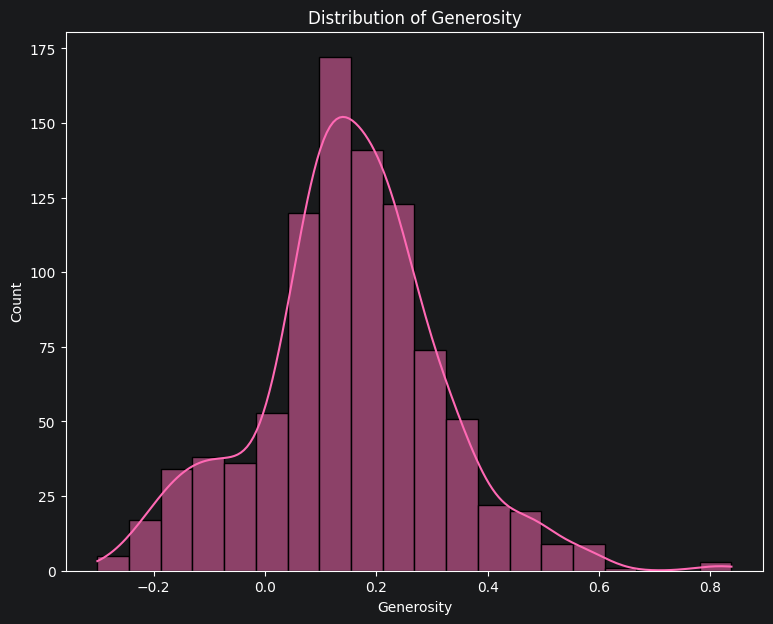

In [128]:
plt.figure(figsize=(9,7))

sns.histplot(
    data=all_data,
    x="Generosity",
    bins=20,
    kde=True,
    color = "#FF69B4"
)

plt.title("Distribution of Generosity")
plt.xlabel("Generosity")
plt.ylabel("Count")

plt.show()

##### The histogram shows the distribution of the Generosity indicator across all countries and years included in the dataset.
 The distribution is right-skewed, with most values concentrated between -0.2 and 0.4, and a long tail extending toward higher values. This suggests that while most countries report relatively low or moderate levels of generosity, a smaller number of countries stand out with noticeably higher scores.

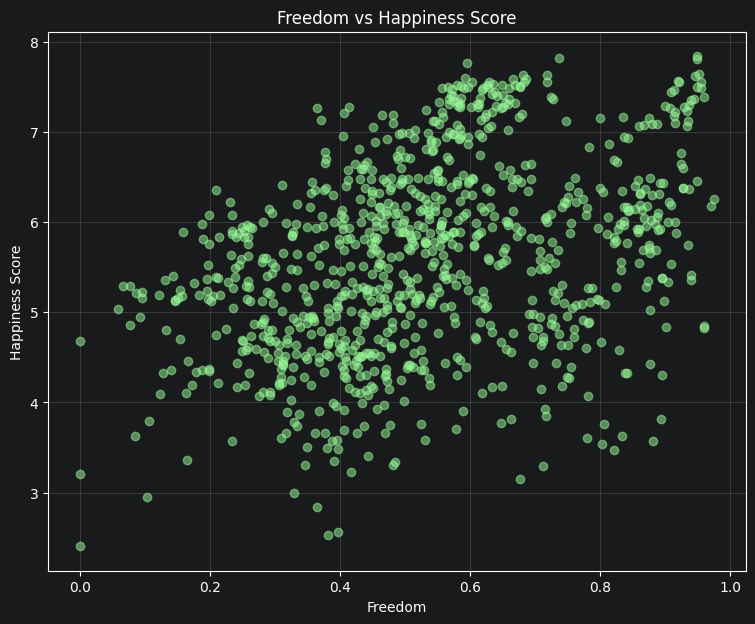

In [168]:
plt.figure(figsize=(9,7))
plt.scatter(all_data["Freedom"], all_data["Happiness Score"],
            alpha=0.5, color="#98FB98")
plt.title("Freedom vs Happiness Score")
plt.xlabel("Freedom")
plt.ylabel("Happiness Score")
plt.grid(alpha=0.3)
plt.show()

The scatter plot reveals a positive relationship between freedom and happiness — countries where people report higher freedom to make life choices tend to score higher on the happiness scale.

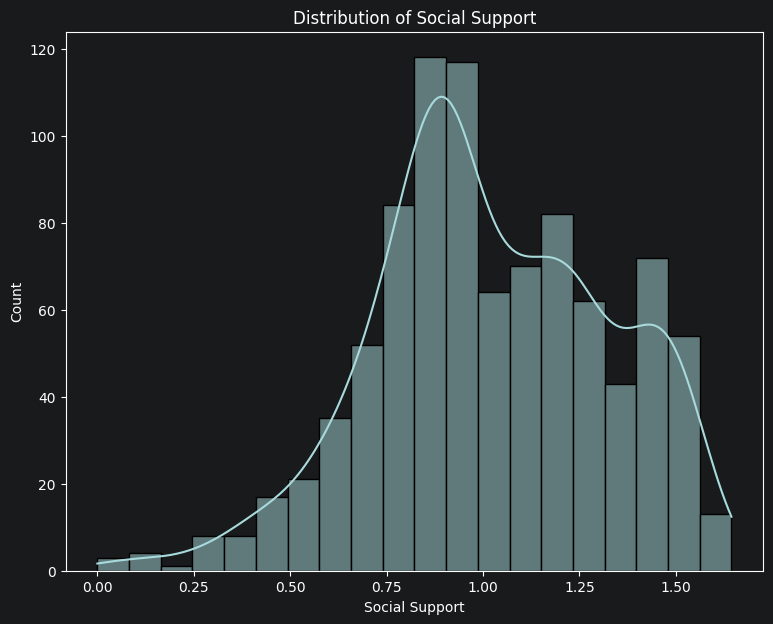

In [129]:
plt.figure(figsize=(9,7))

sns.histplot(
    data=all_data,
    x="Family",
    bins=20,
    kde=True,
    color="#A8DADC"
)

plt.title("Distribution of Social Support")
plt.xlabel("Social Support")
plt.ylabel("Count")

plt.show()

The histogram shows the distribution of the Social Support indicator across all countries and years in the dataset. Most observations are concentrated between 0.8 and 1.3, indicating that moderate to high levels of social support are common among countries. Very low values occur relatively rarely, while the distribution suggests that social support is generally well developed in most observations included in the dataset.


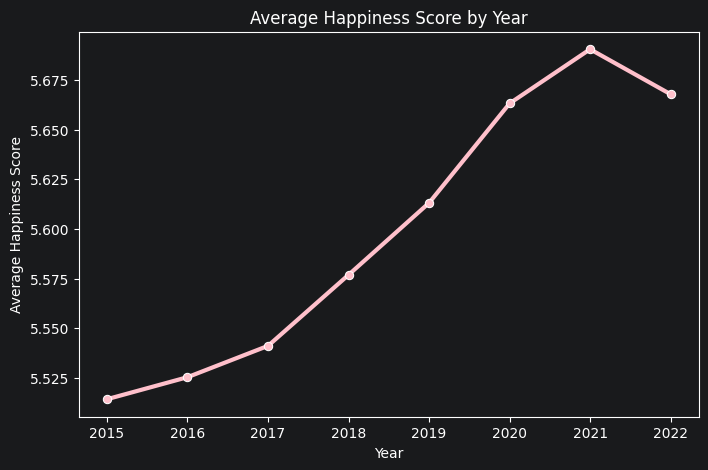

In [130]:
mean_happiness = (
    all_data.groupby("Year")["Happiness Score"]
    .mean()
    .reset_index()
)
plt.figure(figsize=(8,5))

sns.lineplot(
    data=mean_happiness,
    x="Year",
    y="Happiness Score",
    color = "pink",
    marker="o",
    linewidth=3
)

plt.title("Average Happiness Score by Year")
plt.xlabel("Year")
plt.ylabel("Average Happiness Score")

plt.show()

##### The line plot displays the trend in average Happiness Score from 2015 to 2022.
 The average score remains relatively stable, fluctuating between approximately 5.4 and 5.5 from 2015 to 2019. A noticeable drop occurs in 2020, falling below 5.2. In 2021–2022, the values show a partial recovery.

# Quality of Life Dataset

In [131]:
import pandas as pd
import matplotlib.pyplot as plt

In [132]:
data = pd.read_csv("../data_sets/quality_of_life_indices_by_country.csv")

### Dataset description

Dataset source:

https://www.kaggle.com/datasets/marcelobatalhah/quality-of-life-index-by-country/data

The dataset belongs to the socio-economic domain and contains quality of life indicators for different countries between 2015 and 2024. The dataset describes different aspects of living conditions and well-being across countries.

In [133]:
data.head()

,Rank,Country,Quality of Life Index,Purchasing Power Index,Safety Index,Health Care Index,Cost of Living Index,Property Price to Income Ratio,Traffic Commute Time Index,Pollution Index,Climate Index,Year
0,1,Switzerland,222.9,146.5,73.2,66.3,126.0,7.3,25.6,24.1,-,2015
1,2,Germany,195.9,111.8,71.5,75.6,76.3,6.6,31.1,28.3,-,2015
2,3,Sweden,193.9,110.9,57.9,76.3,82.9,9.2,26.9,15.1,-,2015
3,4,United States,192.5,126.1,50.0,67.8,76.5,2.6,36.0,31.4,-,2015
4,5,Finland,190.2,101.2,70.5,69.4,89.7,7.0,33.2,14.9,-,2015


In [134]:
data.shape

(1495, 12)

The dataset contains 1495 rows and 12 columns.

There is one categorical field (Country), one ranking field (Rank), one time-related field (Year), and nine numerical indicators describing different aspects of quality of life.

These indicators include the overall Quality of Life Index, Purchasing Power Index, Safety Index, Health Care Index, Cost of Living Index, Property Price to Income Ratio, Traffic Commute Time Index, Pollution Index, and Climate Index.

In [135]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1495 entries, 0 to 1494
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Rank                            1495 non-null   int64  
 1   Country                         1495 non-null   object 
 2   Quality of Life Index           1495 non-null   float64
 3   Purchasing Power Index          1495 non-null   float64
 4   Safety Index                    1495 non-null   float64
 5   Health Care Index               1495 non-null   float64
 6   Cost of Living Index            1495 non-null   float64
 7   Property Price to Income Ratio  1495 non-null   float64
 8   Traffic Commute Time Index      1495 non-null   float64
 9   Pollution Index                 1495 non-null   float64
 10  Climate Index                   1495 non-null   object 
 11  Year                            1495 non-null   object 
dtypes: float64(8), int64(1), object(3)

According to the data types, most variables are numerical. However, the Year and Climate Index columns are stored as strings, indicating potential formatting issues that require further inspection.

In [136]:
data.isna().sum()

Rank                              0
Country                           0
Quality of Life Index             0
Purchasing Power Index            0
Safety Index                      0
Health Care Index                 0
Cost of Living Index              0
Property Price to Income Ratio    0
Traffic Commute Time Index        0
Pollution Index                   0
Climate Index                     0
Year                              0
dtype: int64

In [137]:
data.duplicated().sum()

np.int64(0)

In [138]:
print("Non-numeric Climate Index values:", (data["Climate Index"] == "-").sum())

Non-numeric Climate Index values: 143


In [139]:
data["Year"].unique()

array(['2015', '2015/2', '2016', '2016/2', '2017', '2017/2', '2018',
       '2018/2', '2019', '2019/2', '2020', '2020/2', '2021', '2021/2',
       '2022', '2022/2', '2023', '2023/2', '2024', '2024/2'], dtype=object)

The dataset is generally of good quality. No explicit missing values or duplicate rows were detected.

However, some inconsistencies were found. The Year column contains values such as "2015/2", while the Climate Index column contains 143 non-numeric entries represented by "-". Because of these inconsistencies, both columns are stored as strings instead of numeric data types. These issues will be corrected during the data cleaning stage.

### Descriptive statistics

In [140]:
statistics = pd.DataFrame({
    "Mean":[data["Quality of Life Index"].mean(),
            data["Purchasing Power Index"].mean(),
            data["Safety Index"].mean(),
            data["Health Care Index"].mean(),
            data["Cost of Living Index"].mean()],

    "Median":[
        data["Quality of Life Index"].median(),
        data["Purchasing Power Index"].median(),
        data["Safety Index"].median(),
        data["Health Care Index"].median(),
        data["Cost of Living Index"].median()],

    "Standard Deviation":
        [
        data["Quality of Life Index"].std(),
        data["Purchasing Power Index"].std(),
        data["Safety Index"].std(),
        data["Health Care Index"].std(),
        data["Cost of Living Index"].std()
        ],

    "Minimum":
        [
        data["Quality of Life Index"].min(),
        data["Purchasing Power Index"].min(),
        data["Safety Index"].min(),
        data["Health Care Index"].min(),
        data["Cost of Living Index"].min()
        ],
    "Maximum":
        [
        data["Quality of Life Index"].max(),
        data["Purchasing Power Index"].max(),
        data["Safety Index"].max(),
        data["Health Care Index"].max(),
        data["Cost of Living Index"].max()
        ]
},
    index=["Quality of Life Index",
           "Purchasing Power Index",
           "Safety Index",
           "Health Care Index",
           "Cost of Living Index"]
)

statistics.round(2)

,Mean,Median,Standard Deviation,Minimum,Maximum
Quality of Life Index,134.16,136.2,40.83,-53.0,285.8
Purchasing Power Index,66.80,60.7,33.28,3.3,210.0
Safety Index,60.10,59.9,13.78,14.7,88.1
Health Care Index,65.21,66.4,10.15,28.3,88.4
Cost of Living Index,53.44,49.2,20.57,17.6,138.2


Among the selected indicators, the Quality of Life Index has the highest variability, while the Health Care Index shows the lowest variability.

The Quality of Life Index also has the widest range of values, indicating substantial differences in living conditions across countries. The mean and median values are relatively close for most indicators, suggesting that the distributions are not strongly skewed.


### Data cleanup

In [141]:
clean_data = data.drop(columns = "Climate Index")
clean_data.head()

,Rank,Country,Quality of Life Index,Purchasing Power Index,Safety Index,Health Care Index,Cost of Living Index,Property Price to Income Ratio,Traffic Commute Time Index,Pollution Index,Year
0,1,Switzerland,222.9,146.5,73.2,66.3,126.0,7.3,25.6,24.1,2015
1,2,Germany,195.9,111.8,71.5,75.6,76.3,6.6,31.1,28.3,2015
2,3,Sweden,193.9,110.9,57.9,76.3,82.9,9.2,26.9,15.1,2015
3,4,United States,192.5,126.1,50.0,67.8,76.5,2.6,36.0,31.4,2015
4,5,Finland,190.2,101.2,70.5,69.4,89.7,7.0,33.2,14.9,2015


Since the Climate Index column contains “-” for all observations from 2015, removing these values would result in losing an entire year of data. Therefore, the Climate Index column was removed from the dataset. Additionally, this indicator was not intended to be used in the correlation analysis or visualizations performed later in the project.

In [142]:
clean_data["Year"] = clean_data["Year"].str.replace("/2", "")
clean_data["Year"] = clean_data["Year"].astype(int)

display(clean_data["Year"].unique())
display(clean_data.dtypes)

array([2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024])

Rank                                int64
Country                            object
Quality of Life Index             float64
Purchasing Power Index            float64
Safety Index                      float64
Health Care Index                 float64
Cost of Living Index              float64
Property Price to Income Ratio    float64
Traffic Commute Time Index        float64
Pollution Index                   float64
Year                                int64
dtype: object

In [143]:
clean_data = clean_data.groupby(["Country","Year"], as_index=False).mean()
clean_data.head(15)

,Country,Year,Rank,Quality of Life Index,Purchasing Power Index,Safety Index,Health Care Index,Cost of Living Index,Property Price to Income Ratio,Traffic Commute Time Index,Pollution Index
0,Albania,2024,70.5,102.00,35.75,54.50,49.25,41.45,14.10,36.70,77.10
1,Argentina,2015,48.0,84.90,71.50,37.05,75.00,67.65,12.25,42.25,57.75
2,Argentina,2016,37.5,137.90,68.10,36.80,73.90,59.70,12.65,40.75,57.30
3,Argentina,2017,37.0,129.65,54.60,36.95,72.75,54.70,11.95,38.40,54.20
4,Argentina,2018,41.0,131.10,60.85,38.15,70.90,45.05,11.90,41.90,54.05
5,Argentina,2019,49.0,121.75,53.50,37.20,69.60,35.90,19.25,42.55,52.10
6,Argentina,2020,55.0,114.75,45.30,37.95,69.25,32.10,24.30,43.05,50.65
7,Argentina,2021,59.5,107.40,31.15,36.45,68.80,36.60,24.55,42.90,50.85
8,Argentina,2022,63.5,107.75,32.15,35.90,69.15,33.40,24.40,43.35,51.05
9,Argentina,2023,59.5,110.60,35.35,35.85,68.60,30.75,22.50,44.00,51.15


The dataset contains semi-annual observations marked with the “/2” suffix. Since this project focuses on yearly analysis, the suffix was removed from the Year column and the values were converted to integers. Then, observations for the same country and year were combined by calculating the mean of the numerical indicators.

In [144]:
years_countries2 = clean_data.groupby("Country")["Year"].nunique()
years_countries2.value_counts().sort_index()

Year
1     11
2      2
3      1
4      2
5      3
6      4
7      9
8      2
9      3
10    61
Name: count, dtype: int64

In [145]:
good_countries2 = years_countries2[years_countries2 == 10].index
clean_data = clean_data[clean_data["Country"].isin(good_countries2)]
clean_data.head()

,Country,Year,Rank,Quality of Life Index,Purchasing Power Index,Safety Index,Health Care Index,Cost of Living Index,Property Price to Income Ratio,Traffic Commute Time Index,Pollution Index
1,Argentina,2015,48.0,84.90,71.50,37.05,75.00,67.65,12.25,42.25,57.75
2,Argentina,2016,37.5,137.90,68.10,36.80,73.90,59.70,12.65,40.75,57.30
3,Argentina,2017,37.0,129.65,54.60,36.95,72.75,54.70,11.95,38.40,54.20
4,Argentina,2018,41.0,131.10,60.85,38.15,70.90,45.05,11.90,41.90,54.05
5,Argentina,2019,49.0,121.75,53.50,37.20,69.60,35.90,19.25,42.55,52.10


Some countries have data for only a few years. To ensure more reliable analysis, only countries with observations available for all years in the dataset were retained.

In [146]:
print(clean_data.shape)
display(clean_data.dtypes)

(610, 11)


Country                            object
Year                                int64
Rank                              float64
Quality of Life Index             float64
Purchasing Power Index            float64
Safety Index                      float64
Health Care Index                 float64
Cost of Living Index              float64
Property Price to Income Ratio    float64
Traffic Commute Time Index        float64
Pollution Index                   float64
dtype: object

After cleaning and filtering, the dataset contains 716 rows and 11 columns. All remaining columns have appropriate data types for further analysis.

### Plots

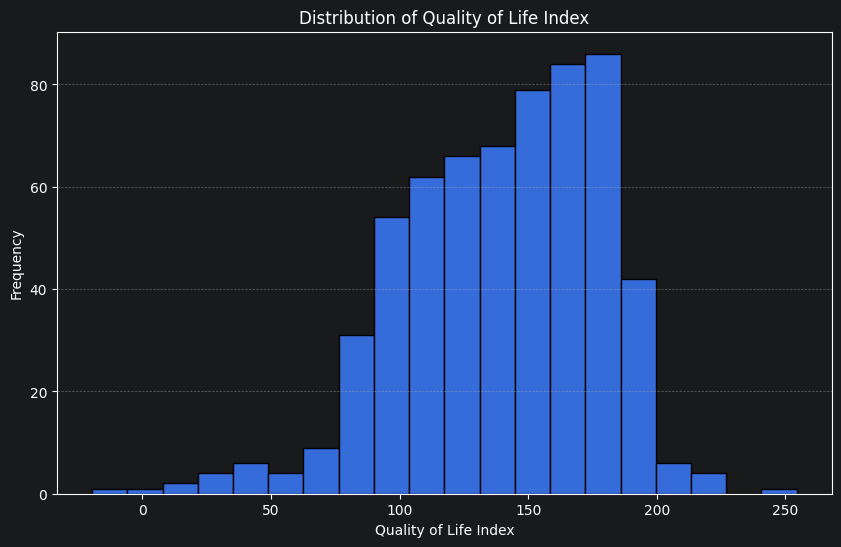

In [147]:
plt.figure(figsize=(10,6))
plt.hist(clean_data["Quality of Life Index"], bins = 20, edgecolor="black")

plt.title("Distribution of Quality of Life Index")
plt.xlabel("Quality of Life Index")
plt.ylabel("Frequency")

plt.grid(axis="y", linestyle="--")

plt.show()


Most observations have Quality of Life Index values between 90 and 190 points, while extremely low and extremely high values are relatively rare.

<Figure size 1000x600 with 0 Axes>

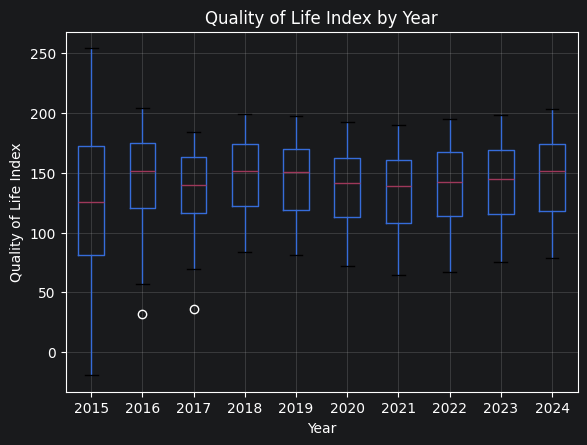

In [148]:
plt.figure(figsize=(10,6))

clean_data.boxplot(
    column="Quality of Life Index",
    by="Year"
)

plt.suptitle("")
plt.title("Quality of Life Index by Year")
plt.xlabel("Year")
plt.ylabel("Quality of Life Index")

plt.grid(alpha=0.3)

plt.show()

The median Quality of Life Index remains relatively stable between 2015 and 2024, showing only minor fluctuations over time. The spread of values across countries is also fairly consistent throughout the observed period, indicating a similar level of variability between countries in most years.

The year 2015 stands out with a noticeably wider range of values, suggesting greater differences in quality of life across countries. Several low-value outliers can also be observed in some years.

### Merged Dataset

### Dataset Description

описание

In [149]:
final_data = pd.merge(clean_data, all_data, on = ["Country", "Year"], how="inner")

In [150]:
final_data.head()

,Country,Year,Rank,Quality of Life Index,Purchasing Power Index,Safety Index,Health Care Index,Cost of Living Index,Property Price to Income Ratio,Traffic Commute Time Index,Pollution Index,Region,Happiness Rank,Happiness Score,Family,Freedom,Generosity,Trust
0,Argentina,2015,48.0,84.90,71.50,37.05,75.00,67.65,12.25,42.25,57.75,Latin America and Caribbean,30,6.574,1.248230,0.449740,0.114510,0.08484
1,Argentina,2016,37.5,137.90,68.10,36.80,73.90,59.70,12.65,40.75,57.30,Latin America and Caribbean,26,6.650,1.066120,0.422840,0.109890,0.07296
2,Argentina,2017,37.0,129.65,54.60,36.95,72.75,54.70,11.95,38.40,54.20,Latin America and Caribbean,24,6.599,1.440451,0.494519,0.109457,0.05974
3,Argentina,2018,41.0,131.10,60.85,38.15,70.90,45.05,11.90,41.90,54.05,Latin America and Caribbean,29,6.388,1.468000,0.570000,0.062000,0.05400
4,Argentina,2019,49.0,121.75,53.50,37.20,69.60,35.90,19.25,42.55,52.10,Latin America and Caribbean,47,6.086,1.432000,0.471000,0.066000,0.05000


In [151]:
final_data.shape

(440, 18)

In [152]:
final_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Country                         440 non-null    object 
 1   Year                            440 non-null    int64  
 2   Rank                            440 non-null    float64
 3   Quality of Life Index           440 non-null    float64
 4   Purchasing Power Index          440 non-null    float64
 5   Safety Index                    440 non-null    float64
 6   Health Care Index               440 non-null    float64
 7   Cost of Living Index            440 non-null    float64
 8   Property Price to Income Ratio  440 non-null    float64
 9   Traffic Commute Time Index      440 non-null    float64
 10  Pollution Index                 440 non-null    float64
 11  Region                          440 non-null    object 
 12  Happiness Rank                  440 

In [153]:
final_data.isna().sum()

Country                           0
Year                              0
Rank                              0
Quality of Life Index             0
Purchasing Power Index            0
Safety Index                      0
Health Care Index                 0
Cost of Living Index              0
Property Price to Income Ratio    0
Traffic Commute Time Index        0
Pollution Index                   0
Region                            0
Happiness Rank                    0
Happiness Score                   0
Family                            0
Freedom                           0
Generosity                        0
Trust                             0
dtype: int64

In [154]:
final_data.duplicated().sum()

np.int64(0)

In [155]:
final_data["Year"].unique()

array([2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022])

In [156]:
final_data.groupby("Country")["Year"].count().value_counts()

Year
8    55
Name: count, dtype: int64

сказать общую инфу

### Data cleanup

In [157]:
final_data = final_data.drop(columns=["Happiness Rank"])
final_data.head()

,Country,Year,Rank,Quality of Life Index,Purchasing Power Index,Safety Index,Health Care Index,Cost of Living Index,Property Price to Income Ratio,Traffic Commute Time Index,Pollution Index,Region,Happiness Score,Family,Freedom,Generosity,Trust
0,Argentina,2015,48.0,84.90,71.50,37.05,75.00,67.65,12.25,42.25,57.75,Latin America and Caribbean,6.574,1.248230,0.449740,0.114510,0.08484
1,Argentina,2016,37.5,137.90,68.10,36.80,73.90,59.70,12.65,40.75,57.30,Latin America and Caribbean,6.650,1.066120,0.422840,0.109890,0.07296
2,Argentina,2017,37.0,129.65,54.60,36.95,72.75,54.70,11.95,38.40,54.20,Latin America and Caribbean,6.599,1.440451,0.494519,0.109457,0.05974
3,Argentina,2018,41.0,131.10,60.85,38.15,70.90,45.05,11.90,41.90,54.05,Latin America and Caribbean,6.388,1.468000,0.570000,0.062000,0.05400
4,Argentina,2019,49.0,121.75,53.50,37.20,69.60,35.90,19.25,42.55,52.10,Latin America and Caribbean,6.086,1.432000,0.471000,0.066000,0.05000


The Happiness Rank column was removed from the final dataset, as it was not required for the analyses performed in this project.

### Detailed overview

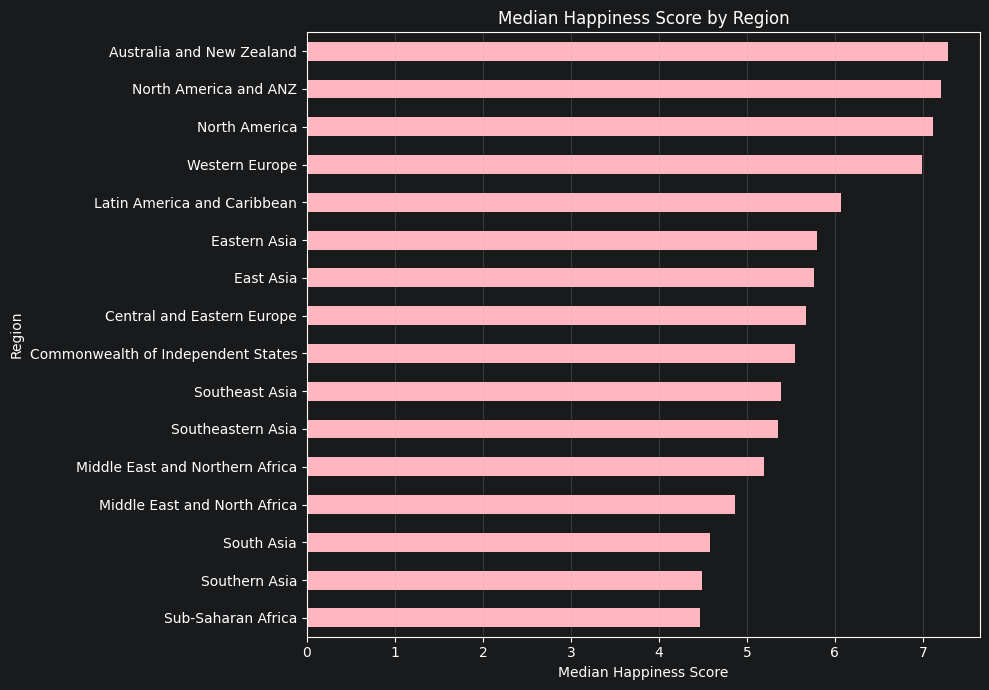

In [170]:
region_happiness = all_data.groupby("Region")["Happiness Score"].median().sort_values()

plt.figure(figsize=(10,7))
region_happiness.plot(kind="barh", color="#FFB6C1")
plt.title("Median Happiness Score by Region")
plt.xlabel("Median Happiness Score")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

The chart shows clear regional differences in happiness. Western Europe and North America consistently report the highest median scores, while Sub-Saharan Africa and South Asia rank lowest

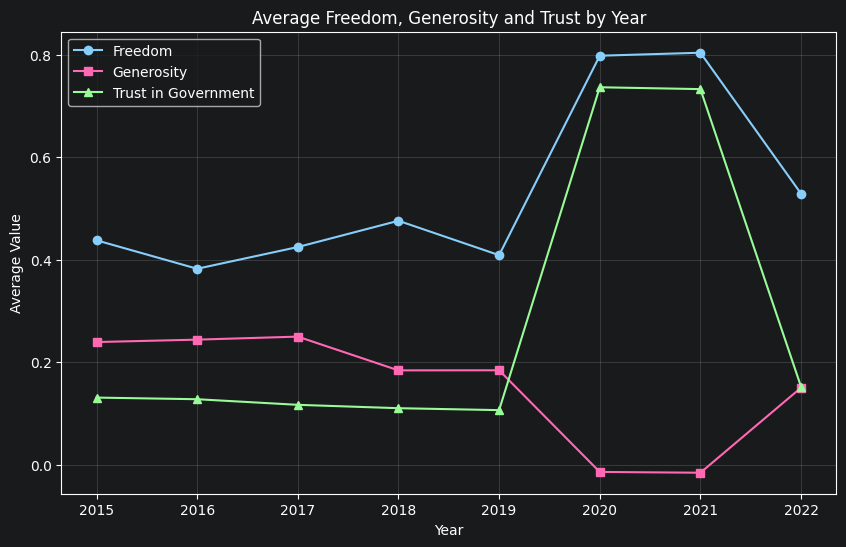

In [169]:
trend = all_data.groupby("Year")[["Freedom", "Generosity", "Trust"]].mean().reset_index()

plt.figure(figsize=(10,6))
plt.plot(trend["Year"], trend["Freedom"], marker="o", label="Freedom", color="#87CEFA")
plt.plot(trend["Year"], trend["Generosity"], marker="s", label="Generosity", color="#FF69B4")
plt.plot(trend["Year"], trend["Trust"], marker="^", label="Trust in Government", color="#98FB98")
plt.title("Average Freedom, Generosity and Trust by Year")
plt.xlabel("Year")
plt.ylabel("Average Value")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

The line chart compares trends in Freedom, Generosity, and Trust from 2015 to 2022. Freedom remains the most stable indicator, while Trust shows a slight decline after 2017. Generosity fluctuates more noticeably, with a visible drop around 2020.

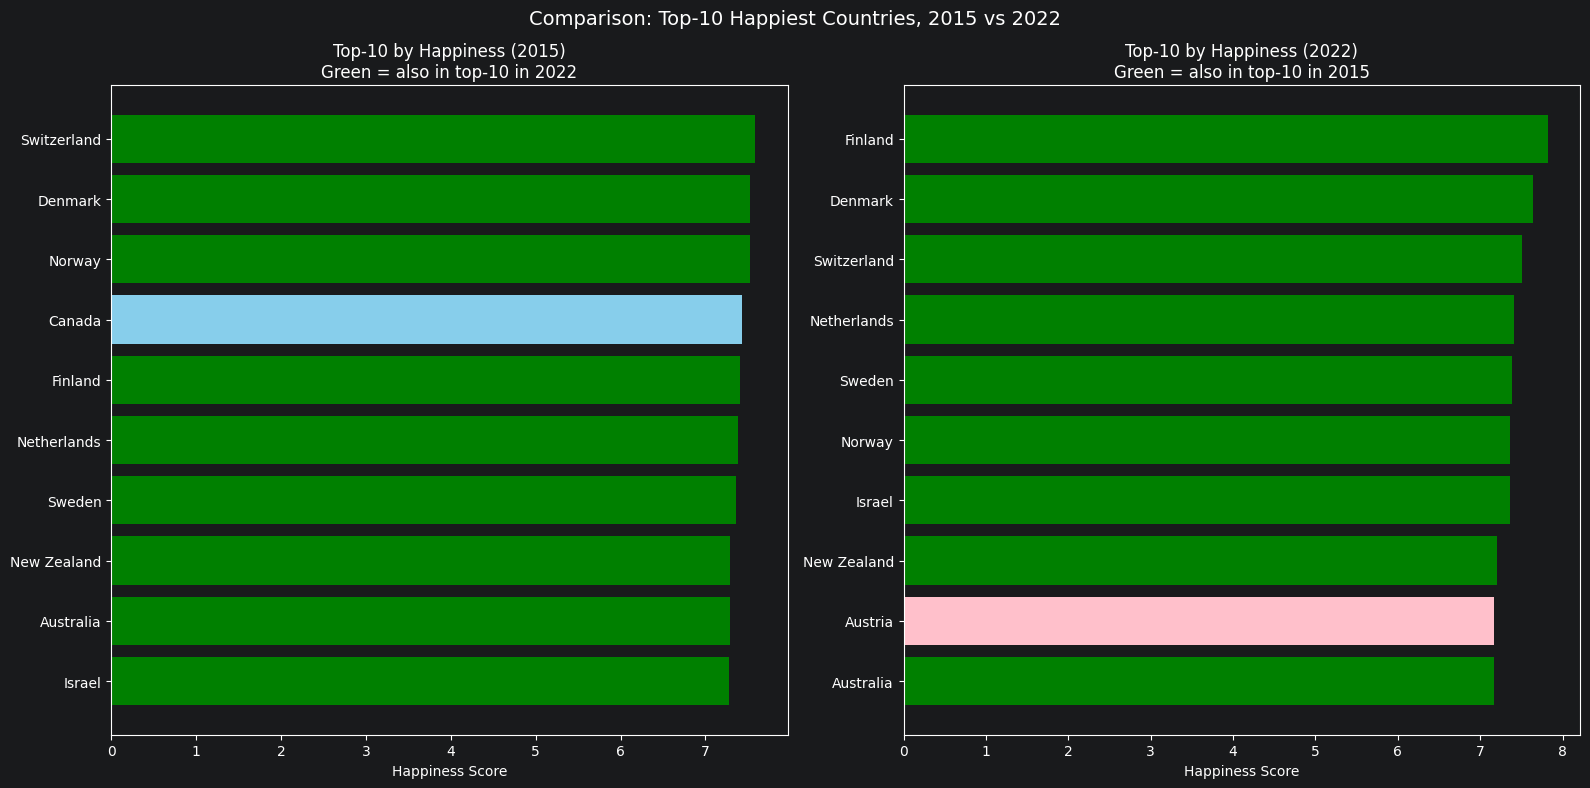

In [159]:
first_year = final_data["Year"].min()
last_year = final_data["Year"].max()

data_first = final_data[final_data["Year"] == first_year]
data_last = final_data[final_data["Year"] == last_year]

top_first = data_first.nlargest(10, "Happiness Score")[["Country", "Happiness Score"]]
top_last = data_last.nlargest(10, "Happiness Score")[["Country", "Happiness Score"]]

first_countries = set(top_first["Country"])
last_countries = set(top_last["Country"])

# зелёный = страна есть в топ-10 в обоих годах
colors_first = ["green" if c in last_countries else "skyblue" for c in top_first["Country"]]
colors_last = ["green" if c in first_countries else "pink" for c in top_last["Country"]]

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].barh(top_first["Country"], top_first["Happiness Score"], color=colors_first)
axes[0].invert_yaxis()
axes[0].set_title(f"Top-10 by Happiness ({first_year})\nGreen = also in top-10 in {last_year}")
axes[0].set_xlabel("Happiness Score")

axes[1].barh(top_last["Country"], top_last["Happiness Score"], color=colors_last)
axes[1].invert_yaxis()
axes[1].set_title(f"Top-10 by Happiness ({last_year})\nGreen = also in top-10 in {first_year}")
axes[1].set_xlabel("Happiness Score")

plt.suptitle(f"Comparison: Top-10 Happiest Countries, {first_year} vs {last_year}", fontsize=14)
plt.tight_layout()
plt.show()

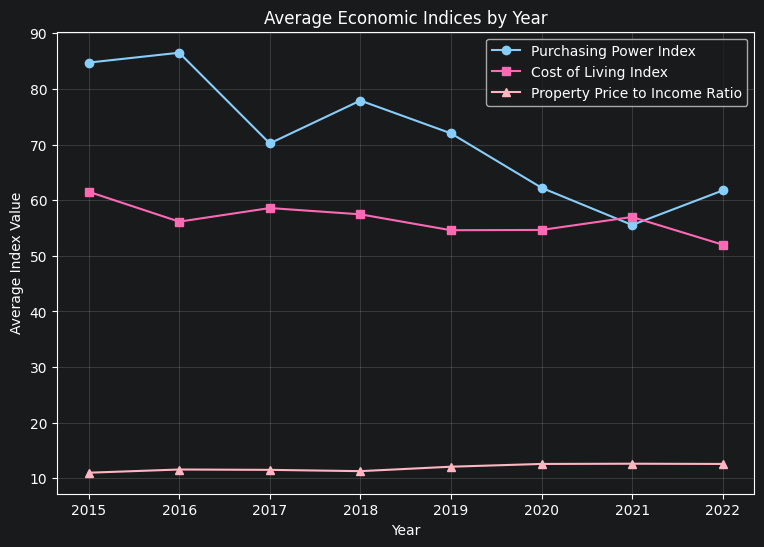

In [158]:
trend_economy = (
    final_data.groupby("Year")[[
        "Purchasing Power Index",
        "Cost of Living Index",
        "Property Price to Income Ratio"
    ]]
    .mean()
    .reset_index()
)

plt.figure(figsize=(9,6))

plt.plot(trend_economy["Year"], trend_economy["Purchasing Power Index"], marker="o", label="Purchasing Power Index", color = "#87CEFA")
plt.plot(trend_economy["Year"], trend_economy["Cost of Living Index"], marker="s", label="Cost of Living Index", color = "#FF69B4")
plt.plot(trend_economy["Year"], trend_economy["Property Price to Income Ratio"], marker="^", label="Property Price to Income Ratio", color = "#FFB6C1")

plt.title("Average Economic Indices by Year")
plt.xlabel("Year")
plt.ylabel("Average Index Value")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

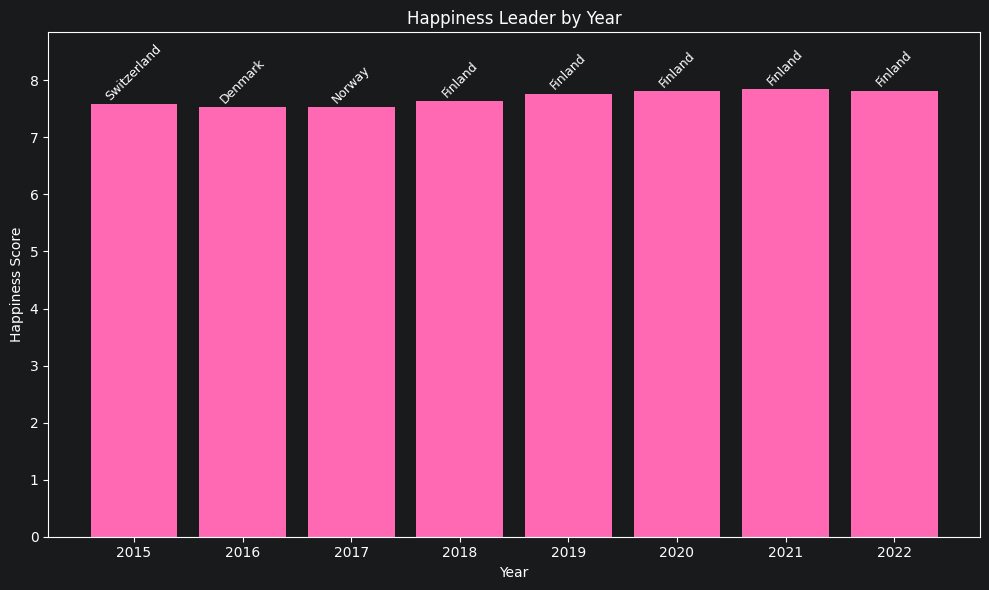

In [160]:
leaders = (
    final_data.loc[final_data.groupby("Year")["Happiness Score"].idxmax()]
    [["Year", "Country", "Happiness Score"]]
    .reset_index(drop=True)
)

plt.figure(figsize=(10,6))
bars = plt.bar(leaders["Year"].astype(str), leaders["Happiness Score"], color="#FF69B4")

for bar, country in zip(bars, leaders["Country"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             country, ha="center", va="bottom", rotation=45, fontsize=9)

plt.title("Happiness Leader by Year")
plt.xlabel("Year")
plt.ylabel("Happiness Score")
plt.ylim(0, leaders["Happiness Score"].max() + 1)
plt.tight_layout()
plt.show()

,High Happiness,Low Happiness
Quality of Life,160.40,116.89
Purchasing Power,89.36,53.35
Safety,61.53,58.34
Pollution,38.67,60.51


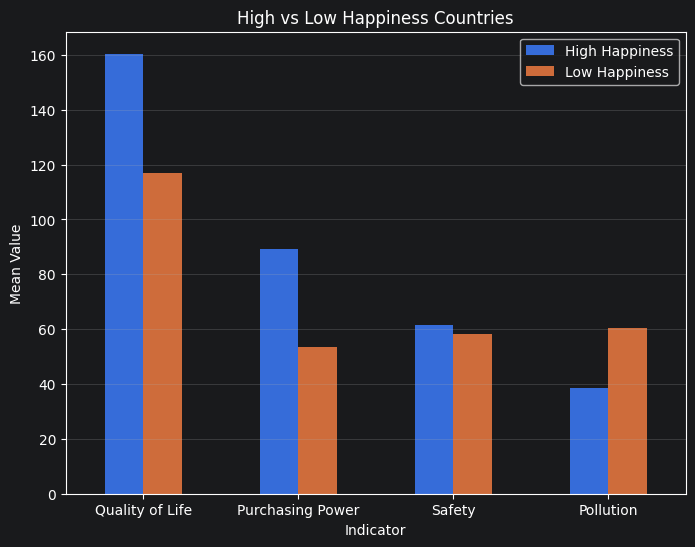

In [161]:
median_happiness = final_data["Happiness Score"].median()

high_happiness = final_data[final_data["Happiness Score"] >= median_happiness]
low_happiness = final_data[final_data["Happiness Score"] < median_happiness]

comparison = pd.DataFrame({
    "High Happiness": [
        high_happiness["Quality of Life Index"].mean(),
        high_happiness["Purchasing Power Index"].mean(),
        high_happiness["Safety Index"].mean(),
        high_happiness["Pollution Index"].mean()
    ],

    "Low Happiness": [
        low_happiness["Quality of Life Index"].mean(),
        low_happiness["Purchasing Power Index"].mean(),
        low_happiness["Safety Index"].mean(),
        low_happiness["Pollution Index"].mean()
    ]
},

index=[
    "Quality of Life",
    "Purchasing Power",
    "Safety",
    "Pollution"
])

comparison = comparison.round(2)
display(comparison)

comparison.plot(
    kind="bar",
    figsize=(8,6)
)

plt.title("High vs Low Happiness Countries")
plt.xlabel("Indicator")
plt.ylabel("Mean Value")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

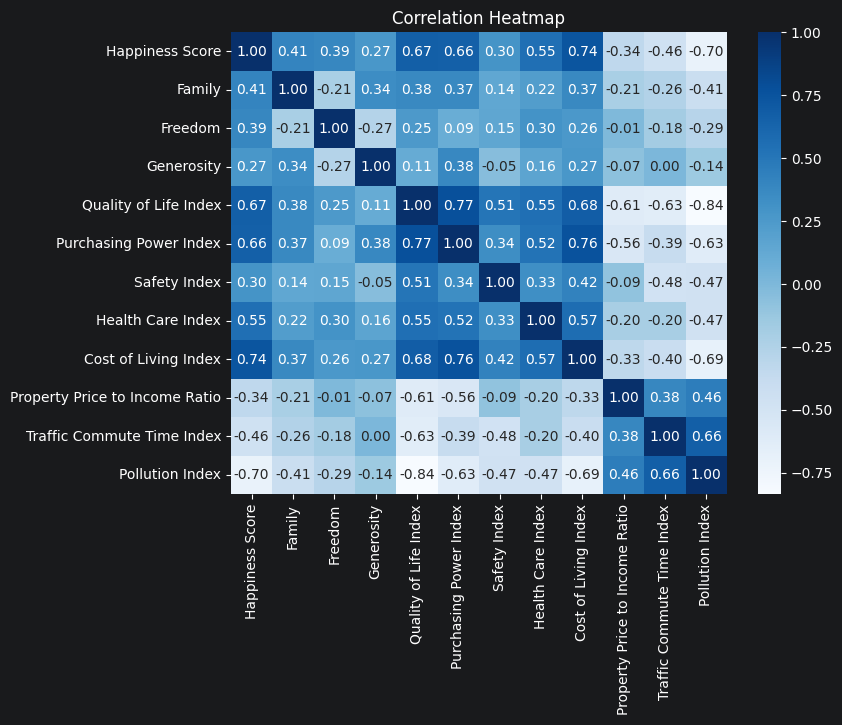

In [162]:
import seaborn as sns

correlation = final_data[["Happiness Score", "Family", "Freedom", "Generosity", "Quality of Life Index", "Purchasing Power Index", "Safety Index", "Health Care Index", "Cost of Living Index", "Property Price to Income Ratio", "Traffic Commute Time Index", "Pollution Index"]].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Hypothesis check


### Hypothesis 1:

 What is the correlation between Purchasing Power Index and Happiness Score for countries with different levels of Freedom?

Correlation between Purchasing Power Index and Happiness Score by Freedom Level:
  Low Freedom: r = 0.560  (n = 77)
  Medium Freedom: r = 0.636  (n = 240)
  High Freedom: r = 0.747  (n = 123)


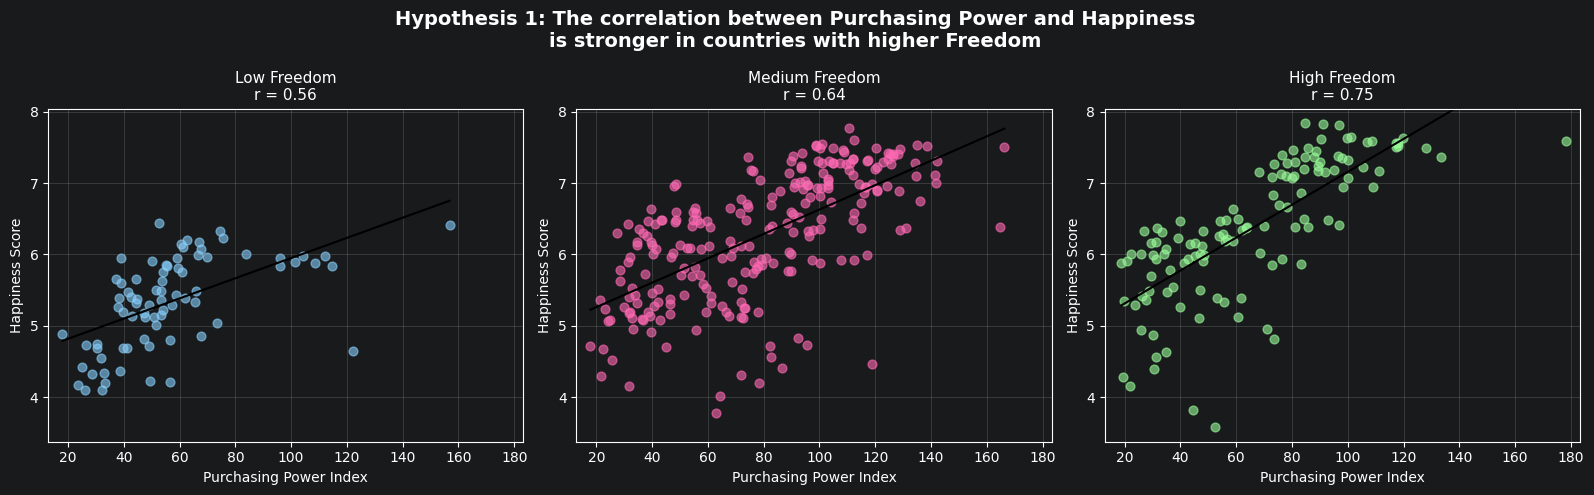

In [163]:
import numpy as np
final_data["Freedom Level"] = pd.cut(
    final_data["Freedom"],
    bins=3,
    labels=["Low Freedom", "Medium Freedom", "High Freedom"]
)

levels = ["Low Freedom", "Medium Freedom", "High Freedom"]
colors = ["#87CEFA", "#FF69B4", "#98FB98"]

print("Correlation between Purchasing Power Index and Happiness Score by Freedom Level:")
for level in levels:
    subset = final_data[final_data["Freedom Level"] == level]
    r = subset["Purchasing Power Index"].corr(subset["Happiness Score"])
    print(f"  {level}: r = {r:.3f}  (n = {len(subset)})")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, level, color in zip(axes, levels, colors):
    subset = final_data[final_data["Freedom Level"] == level]
    r = subset["Purchasing Power Index"].corr(subset["Happiness Score"])

    ax.scatter(subset["Purchasing Power Index"], subset["Happiness Score"],
               alpha=0.6, color=color, s=40)

    m, b = np.polyfit(subset["Purchasing Power Index"], subset["Happiness Score"], 1)
    x_sorted = sorted(subset["Purchasing Power Index"])
    ax.plot(x_sorted, [m*x + b for x in x_sorted], color="black", linewidth=1.5)

    ax.set_title(f"{level}\nr = {r:.2f}", fontsize=11)
    ax.set_xlabel("Purchasing Power Index")
    ax.set_ylabel("Happiness Score")
    ax.set_xlim(final_data["Purchasing Power Index"].min() - 5,
                final_data["Purchasing Power Index"].max() + 5)
    ax.set_ylim(final_data["Happiness Score"].min() - 0.2,
                final_data["Happiness Score"].max() + 0.2)
    ax.grid(alpha=0.3)

plt.suptitle("Hypothesis 1: The correlation between Purchasing Power and Happiness\nis stronger in countries with higher Freedom",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Hypothesis 2:

Does the relationship between Purchasing Power and Happiness differ for countries with different levels of Safety — and has this pattern changed over time (first half vs second half of the study period)?

=== 2015–2018 ===
  Low Safety: r = -0.320, mean Happiness = 5.781, n = 21
  Medium Safety: r = 0.745, mean Happiness = 5.966, n = 129
  High Safety: r = 0.714, mean Happiness = 6.456, n = 70

=== 2019–2022 ===
  Low Safety: r = -0.894, mean Happiness = 5.677, n = 16
  Medium Safety: r = 0.764, mean Happiness = 5.948, n = 120
  High Safety: r = 0.629, mean Happiness = 6.563, n = 84


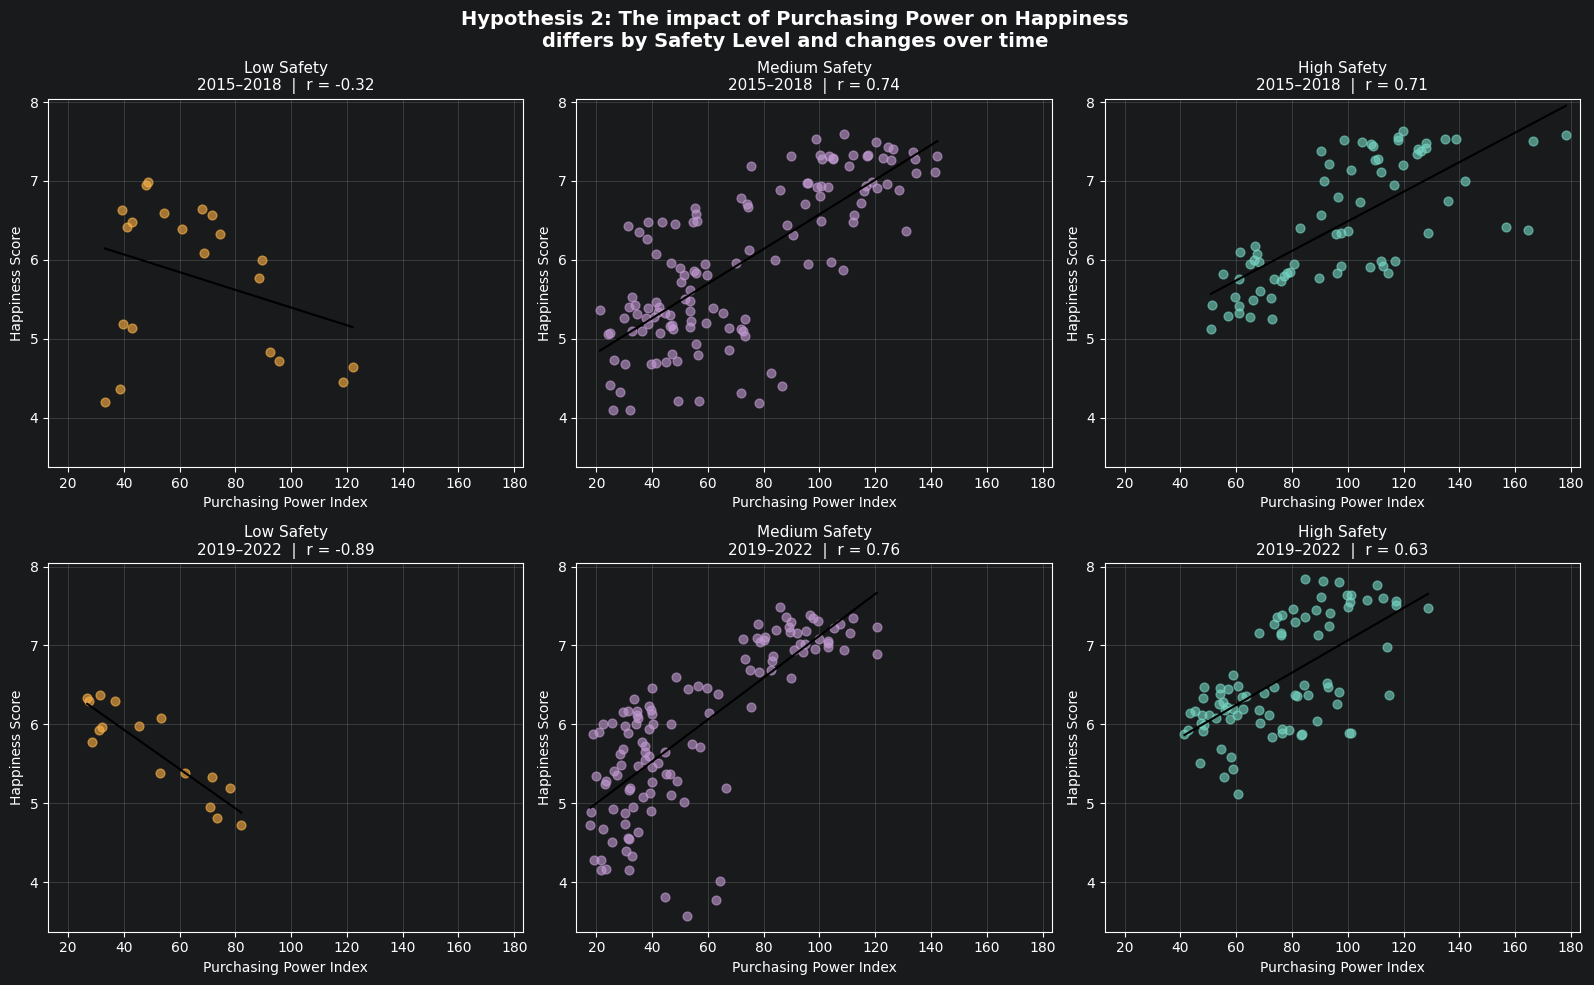

In [164]:
final_data["Safety Level"] = pd.cut(
    final_data["Safety Index"],
    bins=3,
    labels=["Low Safety", "Medium Safety", "High Safety"]
)

early = final_data[final_data["Year"] <= 2018]
late = final_data[final_data["Year"] > 2018]

periods = [("2015–2018", early), ("2019–2022", late)]
levels = ["Low Safety", "Medium Safety", "High Safety"]
colors = ["#FFB347", "#C39BD3", "#76D7C4"]

print("=== 2015–2018 ===")
for level in levels:
    s = early[early["Safety Level"] == level]
    r = s["Purchasing Power Index"].corr(s["Happiness Score"])
    print(f"  {level}: r = {r:.3f}, mean Happiness = {s['Happiness Score'].mean():.3f}, n = {len(s)}")

print("\n=== 2019–2022 ===")
for level in levels:
    s = late[late["Safety Level"] == level]
    r = s["Purchasing Power Index"].corr(s["Happiness Score"])
    print(f"  {level}: r = {r:.3f}, mean Happiness = {s['Happiness Score'].mean():.3f}, n = {len(s)}")

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for row, (period_label, period_data) in enumerate(periods):
    for col, (level, color) in enumerate(zip(levels, colors)):
        ax = axes[row][col]
        subset = period_data[period_data["Safety Level"] == level]

        ax.scatter(subset["Purchasing Power Index"], subset["Happiness Score"],
                   alpha=0.6, color=color, s=40)

        if len(subset) > 2:
            m, b = np.polyfit(subset["Purchasing Power Index"], subset["Happiness Score"], 1)
            x_sorted = sorted(subset["Purchasing Power Index"])
            ax.plot(x_sorted, [m*x + b for x in x_sorted], color="black", linewidth=1.5)
            r = subset["Purchasing Power Index"].corr(subset["Happiness Score"])
            ax.set_title(f"{level}\n{period_label}  |  r = {r:.2f}", fontsize=11)
        else:
            ax.set_title(f"{level}\n{period_label}  |  n too small", fontsize=11)

        ax.set_xlabel("Purchasing Power Index")
        ax.set_ylabel("Happiness Score")
        ax.set_xlim(final_data["Purchasing Power Index"].min() - 5,
                    final_data["Purchasing Power Index"].max() + 5)
        ax.set_ylim(final_data["Happiness Score"].min() - 0.2,
                    final_data["Happiness Score"].max() + 0.2)
        ax.grid(alpha=0.3)

plt.suptitle("Hypothesis 2: The impact of Purchasing Power on Happiness\ndiffers by Safety Level and changes over time",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


### Hypothesis 3:

The three factors most strongly correlated with the Quality of Life Index are also the three factors most strongly correlated with the Happiness Score.

Top-3 correlated with Quality of Life Index: ['Pollution Index', 'Purchasing Power Index', 'Cost of Living Index']
Top-3 correlated with Happiness Score: ['Cost of Living Index', 'Pollution Index', 'Purchasing Power Index']
Overlap: {'Purchasing Power Index', 'Pollution Index', 'Cost of Living Index'}


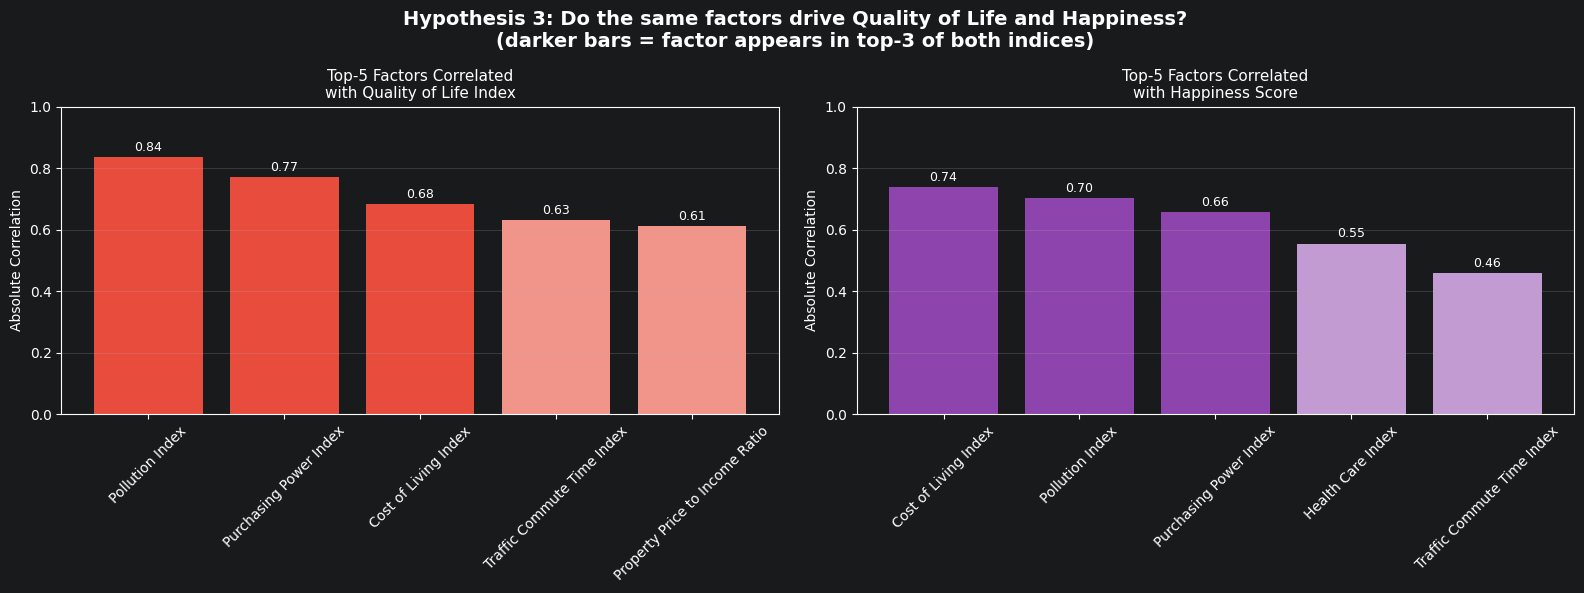

In [165]:
cols = ["Family", "Freedom", "Generosity",
        "Purchasing Power Index", "Safety Index",
        "Health Care Index", "Cost of Living Index",
        "Property Price to Income Ratio",
        "Traffic Commute Time Index", "Pollution Index"]

corr_qol = (final_data[cols + ["Quality of Life Index"]]
            .corr()["Quality of Life Index"]
            .drop("Quality of Life Index")
            .abs()
            .sort_values(ascending=False))

corr_hap = (final_data[cols + ["Happiness Score"]]
            .corr()["Happiness Score"]
            .drop("Happiness Score")
            .abs()
            .sort_values(ascending=False))

top3_qol = list(corr_qol.head(3).index)
top3_hap = list(corr_hap.head(3).index)
overlap = set(top3_qol) & set(top3_hap)

print("Top-3 correlated with Quality of Life Index:", top3_qol)
print("Top-3 correlated with Happiness Score:", top3_hap)
print("Overlap:", overlap)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bars0 = axes[0].bar(corr_qol.head(5).index, corr_qol.head(5).values,
                     color=["#E74C3C" if f in overlap else "#F1948A" for f in corr_qol.head(5).index])
axes[0].set_title("Top-5 Factors Correlated\nwith Quality of Life Index", fontsize=11)
axes[0].set_ylabel("Absolute Correlation")
axes[0].tick_params(axis="x", rotation=45)
axes[0].set_ylim(0, 1)
axes[0].grid(axis="y", alpha=0.3)

for bar, val in zip(bars0, corr_qol.head(5).values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.01,
                 f"{val:.2f}", ha="center", va="bottom", fontsize=9)

bars1 = axes[1].bar(corr_hap.head(5).index, corr_hap.head(5).values,
                     color=["#8E44AD" if f in overlap else "#C39BD3" for f in corr_hap.head(5).index])
axes[1].set_title("Top-5 Factors Correlated\nwith Happiness Score", fontsize=11)
axes[1].set_ylabel("Absolute Correlation")
axes[1].tick_params(axis="x", rotation=45)
axes[1].set_ylim(0, 1)
axes[1].grid(axis="y", alpha=0.3)

for bar, val in zip(bars1, corr_hap.head(5).values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.01,
                 f"{val:.2f}", ha="center", va="bottom", fontsize=9)

plt.suptitle("Hypothesis 3: Do the same factors drive Quality of Life and Happiness?\n(darker bars = factor appears in top-3 of both indices)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Data transformation

In [166]:
final_data["Affordability"] = ( final_data["Purchasing Power Index"] / final_data["Cost of Living Index"])

final_data[["Country", "Year", "Affordability"]].head(10)

,Country,Year,Affordability
0,Argentina,2015,1.056911
1,Argentina,2016,1.140704
2,Argentina,2017,0.998172
3,Argentina,2018,1.350721
4,Argentina,2019,1.490251
5,Argentina,2020,1.411215
6,Argentina,2021,0.851093
7,Argentina,2022,0.962575
8,Australia,2015,1.421610
9,Australia,2016,1.798989


A new variable called Affordability was created by dividing Purchasing Power Index by Cost of Living Index. This indicator reflects the relationship between purchasing power and living expenses. Higher values indicate that residents have greater purchasing power relative to the cost of living, making everyday life more affordable.

In [167]:
final_data["Health_and_Safety"] = (final_data["Health Care Index"] + final_data["Safety Index"]) / 2

final_data[["Country", "Year", "Health_and_Safety"]].head()

,Country,Year,Health_and_Safety
0,Argentina,2015,56.025
1,Argentina,2016,55.350
2,Argentina,2017,54.850
3,Argentina,2018,54.525
4,Argentina,2019,53.400


A new variable called Health_and_Safety was created as the average of Health Care Index and Safety Index. It combines healthcare quality and public safety into a single indicator, providing a broader measure of living conditions.